# Experiments 1 & 2 — Combined Figure with Curve Fits

This notebook benchmarks the methods from Section 1 / Figure 2 of <File>Poster___numerical_linear_algebra (3).pdf</File> and adds two fitted models for **all cases**:

1. `t(n) = a * n^b` where `a` and `b` are estimated.
2. `t(n) = c * n^3` where `c` is estimated.

The method families are:
- Dense: LU, Matrix Inverse, QR
- SPD: Cholesky, LU, Matrix Inverse, QR

The benchmark sizes are:
`n = 50, 100, 200, 400, 800`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import perf_counter
from scipy.linalg import lu_factor, lu_solve, cho_factor, cho_solve
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')


## Matrix generators

In [2]:
def generate_general_dense(n: int, rng: np.random.Generator):
    A = rng.standard_normal((n, n)) + 5.0 * np.eye(n)
    b = rng.standard_normal(n)
    return A, b


def generate_spd_matrix(n: int, rng: np.random.Generator, alpha: float = 1e-2):
    M = rng.standard_normal((n, n))
    A = M.T @ M + alpha * n * np.eye(n)
    b = rng.standard_normal(n)
    return A, b


## Solvers

In [3]:
def solve_lu(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    lu, piv = lu_factor(A, check_finite=False)
    return lu_solve((lu, piv), b, check_finite=False)


def solve_matrix_inverse(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    return np.linalg.inv(A) @ b


def solve_qr(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    Q, R = np.linalg.qr(A)
    return np.linalg.solve(R, Q.T @ b)


def solve_cholesky(A: np.ndarray, b: np.ndarray) -> np.ndarray:
    c, low = cho_factor(A, lower=True, check_finite=False)
    return cho_solve((c, low), b, check_finite=False)


METHODS_DENSE = {
    'Dense - LU': solve_lu,
    'Dense - MatrixInverse': solve_matrix_inverse,
    'Dense - QR': solve_qr,
}

METHODS_SPD = {
    'SPD - Cholesky': solve_cholesky,
    'SPD - LU': solve_lu,
    'SPD - MatrixInverse': solve_matrix_inverse,
    'SPD - QR': solve_qr,
}


## Benchmark helpers

In [4]:
def benchmark_solver(solver, A: np.ndarray, b: np.ndarray, repeats: int = 3, warmups: int = 1):
    for _ in range(warmups):
        solver(A, b)

    timings = []
    x_last = None
    for _ in range(repeats):
        t0 = perf_counter()
        x_last = solver(A, b)
        timings.append(perf_counter() - t0)

    x_ref = np.linalg.solve(A, b)
    rel_residual = np.linalg.norm(A @ x_last - b) / np.linalg.norm(b)
    rel_error_vs_ref = np.linalg.norm(x_last - x_ref) / np.linalg.norm(x_ref)

    return {
        'mean_s': float(np.mean(timings)),
        'std_s': float(np.std(timings, ddof=1)) if len(timings) > 1 else 0.0,
        'rel_residual': float(rel_residual),
        'rel_error_vs_ref': float(rel_error_vs_ref),
    }


def run_experiment(dimensions, generator, methods, rng, realizations=3, repeats=3):
    rows = []
    for n in dimensions:
        for trial in range(realizations):
            A, b = generator(n, rng)
            for method_name, solver in methods.items():
                stats = benchmark_solver(solver, A, b, repeats=repeats)
                rows.append({
                    'n': n,
                    'trial': trial,
                    'Method': method_name,
                    **stats,
                })
    return pd.DataFrame(rows)


## Run Experiments 1 & 2

In [ ]:
dimensions = (50, 100, 200, 400, 800)
rng = np.random.default_rng(42)

dense_results = run_experiment(
    dimensions=dimensions,
    generator=generate_general_dense,
    methods=METHODS_DENSE,
    rng=rng,
    realizations=3,
    repeats=20,
)

spd_results = run_experiment(
    dimensions=dimensions,
    generator=generate_spd_matrix,
    methods=METHODS_SPD,
    rng=rng,
    realizations=3,
    repeats=20,
)

all_results = pd.concat([dense_results, spd_results], ignore_index=True)
all_results.head()


,n,trial,Method,mean_s,std_s,rel_residual,rel_error_vs_ref
0,50,0,Dense - LU,4.73333e-05,1.61544e-05,2.5896e-15,0
1,50,0,Dense - MatrixInverse,0.0002114,8.79859e-05,2.40364e-15,5.18897e-16
2,50,0,Dense - QR,0.00818593,0.0101426,1.98584e-15,3.053e-15
3,50,1,Dense - LU,0.0001717,0.000146698,1.9228e-15,0
4,50,1,Dense - MatrixInverse,0.0012963,0.00192769,6.55553e-15,9.01389e-16


## Summary table

In [6]:
summary = (all_results
           .groupby(['n', 'Method'], as_index=False)
           .agg(mean_time_s=('mean_s', 'mean'),
                std_time_s=('mean_s', 'std'),
                mean_rel_residual=('rel_residual', 'mean'),
                mean_rel_error_vs_ref=('rel_error_vs_ref', 'mean')))
summary


,n,Method,mean_time_s,std_time_s,mean_rel_residual,mean_rel_error_vs_ref
0,50,Dense - LU,9.05222e-05,7.03501e-05,1.98398e-15,0
1,50,Dense - MatrixInverse,0.000550289,0.000646965,3.68901e-15,7.62066e-16
2,50,Dense - QR,0.00332788,0.00420779,2.26411e-15,2.95847e-15
3,50,SPD - Cholesky,4.43111e-05,7.31849e-06,7.10707e-15,8.57292e-15
4,50,SPD - LU,4.43333e-05,3.24157e-06,7.9249e-15,0
5,50,SPD - MatrixInverse,0.000193278,8.66e-05,9.47135e-15,3.83727e-16
6,50,SPD - QR,0.000947144,0.00106951,1.21858e-14,8.86108e-15
7,100,Dense - LU,0.000153311,7.75389e-05,1.52159e-11,0
8,100,Dense - MatrixInverse,0.000267678,7.26487e-05,8.8802e-12,2.81417e-15
9,100,Dense - QR,0.0008894,0.000208327,5.40265e-12,1.55362e-12


## Original combined graph (same structure as Section 1 / Figure 2)

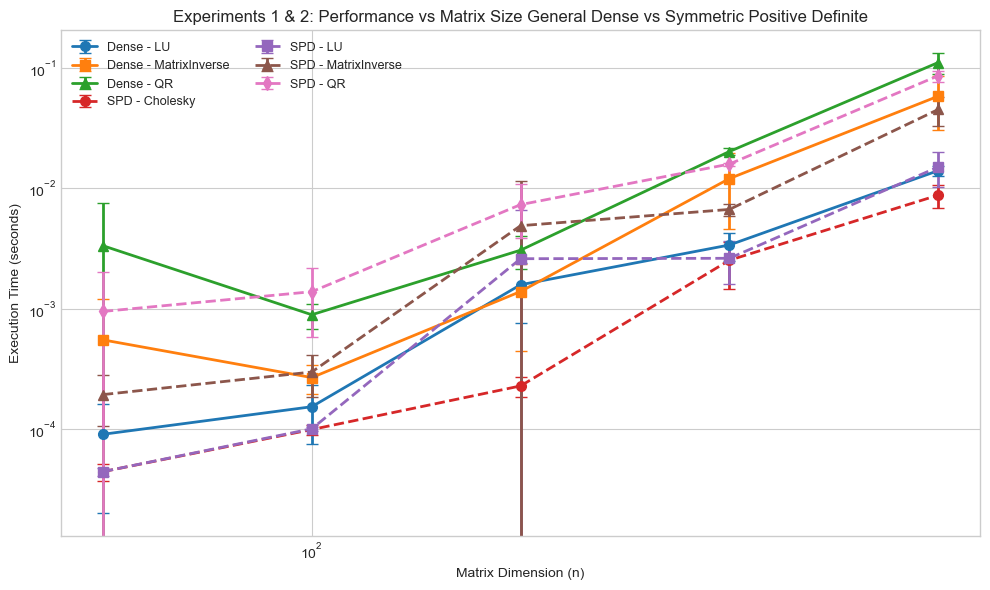

In [8]:
plot_order = [
    'Dense - LU',
    'Dense - MatrixInverse',
    'Dense - QR',
    'SPD - Cholesky',
    'SPD - LU',
    'SPD - MatrixInverse',
    'SPD - QR',
]

styles = {
    'Dense - LU': dict(marker='o', linestyle='-', linewidth=2),
    'Dense - MatrixInverse': dict(marker='s', linestyle='-', linewidth=2),
    'Dense - QR': dict(marker='^', linestyle='-', linewidth=2),
    'SPD - Cholesky': dict(marker='o', linestyle='--', linewidth=2),
    'SPD - LU': dict(marker='s', linestyle='--', linewidth=2),
    'SPD - MatrixInverse': dict(marker='^', linestyle='--', linewidth=2),
    'SPD - QR': dict(marker='d', linestyle='--', linewidth=2),
}

fig, ax = plt.subplots(figsize=(10, 6))
for method in plot_order:
    sub = summary[summary['Method'] == method].sort_values('n')
    st = styles[method]
    ax.errorbar(
        sub['n'], sub['mean_time_s'], yerr=sub['std_time_s'],
        label=method, capsize=4, ms=7, **st
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Dimension (n)')
ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Experiments 1 & 2: Performance vs Matrix Size General Dense vs Symmetric Positive Definite')
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## Curve fitting for all cases

For each method, estimate:
- `t(n) = a * n^b`
- `t(n) = c * n^3`


In [9]:
def fit_power_law_ab(n, t):
    n = np.asarray(n, dtype=float)
    t = np.asarray(t, dtype=float)
    b, log_a = np.polyfit(np.log(n), np.log(t), 1)
    a = np.exp(log_a)
    return float(a), float(b)


def fit_cubic_prefactor(n, t):
    n = np.asarray(n, dtype=float)
    t = np.asarray(t, dtype=float)
    x = n**3
    c = np.dot(x, t) / np.dot(x, x)
    return float(c)


def r2_score(y, yhat):
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - np.mean(y))**2)
    return float(1.0 - ss_res / ss_tot) if ss_tot > 0 else float('nan')


fit_rows = []
for method, sub in summary.groupby('Method'):
    sub = sub.sort_values('n')
    n = sub['n'].to_numpy(dtype=float)
    t = sub['mean_time_s'].to_numpy(dtype=float)

    a_hat, b_hat = fit_power_law_ab(n, t)
    c_hat = fit_cubic_prefactor(n, t)

    y_ab = a_hat * n**b_hat
    y_c3 = c_hat * n**3

    fit_rows.append({
        'Method': method,
        'a_hat': a_hat,
        'b_hat': b_hat,
        'c_hat_for_n3': c_hat,
        'R2_a_n_b': r2_score(t, y_ab),
        'R2_c_n3': r2_score(t, y_c3),
    })

fit_table = pd.DataFrame(fit_rows).sort_values('Method').reset_index(drop=True)
fit_table


,Method,a_hat,b_hat,c_hat_for_n3,R2_a_n_b,R2_c_n3
0,Dense - LU,4.26931e-08,1.90024,2.77402e-11,0.9964,0.967084
1,Dense - MatrixInverse,1.18952e-07,1.89276,1.14456e-10,0.821669,0.990745
2,Dense - QR,3.1609e-06,1.46063,2.17234e-10,0.648419,0.994019
3,SPD - Cholesky,1.21678e-08,1.99202,1.74381e-11,0.957565,0.963814
4,SPD - LU,9.6177e-09,2.15048,2.95255e-11,0.94974,0.960628
5,SPD - MatrixInverse,5.42967e-08,2.02095,8.82629e-11,0.971219,0.987135
6,SPD - QR,1.05016e-06,1.65207,1.68885e-10,0.917208,0.98771


## Fitted formulas by method

In [10]:
formula_table = fit_table.copy()
formula_table['fit_a_n_b_formula'] = formula_table.apply(
    lambda r: f"t(n) ≈ {r['a_hat']:.6e} * n^{r['b_hat']:.6f}", axis=1
)
formula_table['fit_c_n3_formula'] = formula_table.apply(
    lambda r: f"t(n) ≈ {r['c_hat_for_n3']:.6e} * n^3", axis=1
)
formula_table[['Method', 'fit_a_n_b_formula', 'fit_c_n3_formula', 'R2_a_n_b', 'R2_c_n3']]


,Method,fit_a_n_b_formula,fit_c_n3_formula,R2_a_n_b,R2_c_n3
0,Dense - LU,t(n) ≈ 4.269311e-08 * n^1.900242,t(n) ≈ 2.774017e-11 * n^3,0.9964,0.967084
1,Dense - MatrixInverse,t(n) ≈ 1.189525e-07 * n^1.892760,t(n) ≈ 1.144564e-10 * n^3,0.821669,0.990745
2,Dense - QR,t(n) ≈ 3.160900e-06 * n^1.460628,t(n) ≈ 2.172345e-10 * n^3,0.648419,0.994019
3,SPD - Cholesky,t(n) ≈ 1.216776e-08 * n^1.992024,t(n) ≈ 1.743805e-11 * n^3,0.957565,0.963814
4,SPD - LU,t(n) ≈ 9.617697e-09 * n^2.150480,t(n) ≈ 2.952555e-11 * n^3,0.94974,0.960628
5,SPD - MatrixInverse,t(n) ≈ 5.429674e-08 * n^2.020952,t(n) ≈ 8.826289e-11 * n^3,0.971219,0.987135
6,SPD - QR,t(n) ≈ 1.050157e-06 * n^1.652075,t(n) ≈ 1.688846e-10 * n^3,0.917208,0.98771


## Curves evaluated at the benchmark sizes

In [11]:
fit_curves_rows = []
for method, sub in summary.groupby('Method'):
    sub = sub.sort_values('n')
    n = sub['n'].to_numpy(dtype=float)
    t = sub['mean_time_s'].to_numpy(dtype=float)
    a_hat, b_hat = fit_power_law_ab(n, t)
    c_hat = fit_cubic_prefactor(n, t)

    for ni, ti in zip(n, t):
        fit_curves_rows.append({
            'Method': method,
            'n': ni,
            'observed_mean_time_s': ti,
            'fit_a_n_b': a_hat * ni**b_hat,
            'fit_c_n3': c_hat * ni**3,
        })

fit_curves = pd.DataFrame(fit_curves_rows)
fit_curves


,Method,n,observed_mean_time_s,fit_a_n_b,fit_c_n3
0,Dense - LU,50,9.05222e-05,7.22458e-05,3.46752e-06
1,Dense - LU,100,0.000153311,0.000269676,2.77402e-05
2,Dense - LU,200,0.00157836,0.00100664,0.000221921
3,Dense - LU,400,0.00337499,0.00375753,0.00177537
4,Dense - LU,800,0.0139816,0.0140259,0.014203
5,Dense - MatrixInverse,50,0.000550289,0.000195486,1.43071e-05
6,Dense - MatrixInverse,100,0.000267678,0.000725927,0.000114456
7,Dense - MatrixInverse,200,0.00138698,0.00269569,0.000915652
8,Dense - MatrixInverse,400,0.0120113,0.0100103,0.00732521
9,Dense - MatrixInverse,800,0.0580081,0.0371728,0.0586017


## Combined graph with fitted curves

Measured curves are shown together with:
- dotted line: `a * n^b`
- dash-dot line: `c * n^3`


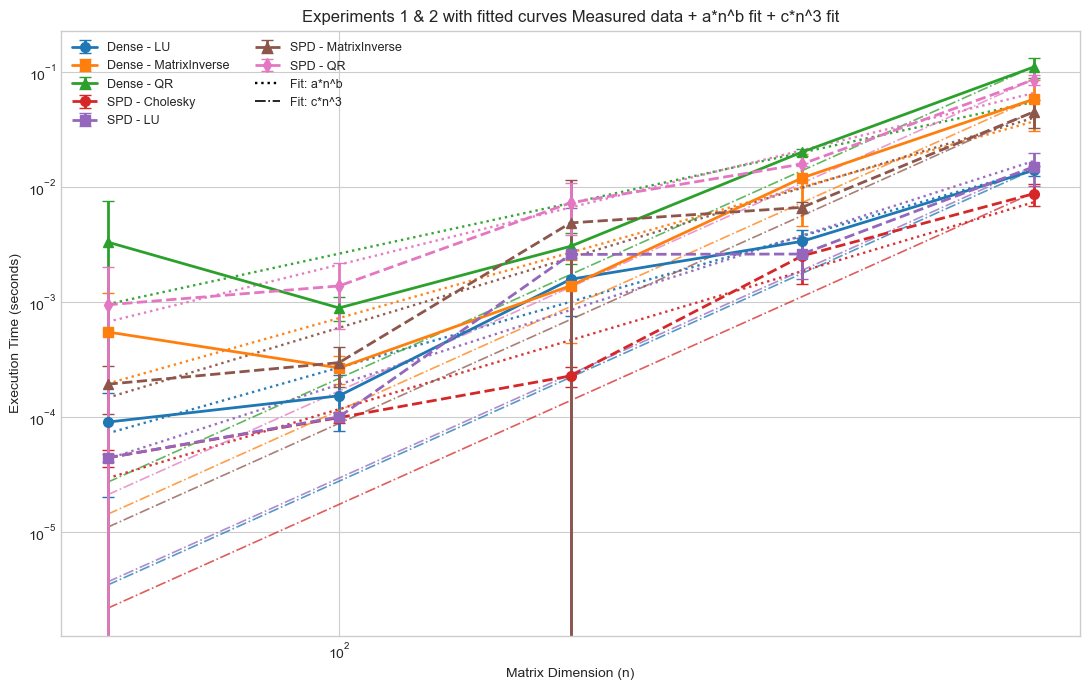

In [13]:
plot_order = [
    'Dense - LU',
    'Dense - MatrixInverse',
    'Dense - QR',
    'SPD - Cholesky',
    'SPD - LU',
    'SPD - MatrixInverse',
    'SPD - QR',
]

base_styles = {
    'Dense - LU': dict(color='C0', marker='o', linestyle='-', linewidth=2),
    'Dense - MatrixInverse': dict(color='C1', marker='s', linestyle='-', linewidth=2),
    'Dense - QR': dict(color='C2', marker='^', linestyle='-', linewidth=2),
    'SPD - Cholesky': dict(color='C3', marker='o', linestyle='--', linewidth=2),
    'SPD - LU': dict(color='C4', marker='s', linestyle='--', linewidth=2),
    'SPD - MatrixInverse': dict(color='C5', marker='^', linestyle='--', linewidth=2),
    'SPD - QR': dict(color='C6', marker='d', linestyle='--', linewidth=2),
}

fig, ax = plt.subplots(figsize=(11, 7))
for method in plot_order:
    sub = summary[summary['Method'] == method].sort_values('n')
    st = base_styles[method]
    color = st['color']

    ax.errorbar(
        sub['n'], sub['mean_time_s'], yerr=sub['std_time_s'],
        label=method, capsize=4, ms=7, marker=st['marker'],
        linestyle=st['linestyle'], linewidth=st['linewidth'], color=color
    )

    n = sub['n'].to_numpy(dtype=float)
    t = sub['mean_time_s'].to_numpy(dtype=float)
    a_hat, b_hat = fit_power_law_ab(n, t)
    c_hat = fit_cubic_prefactor(n, t)

    n_smooth = np.geomspace(n.min(), n.max(), 200)
    ax.plot(n_smooth, a_hat * n_smooth**b_hat, color=color, linestyle=':', linewidth=1.7, alpha=0.95)
    ax.plot(n_smooth, c_hat * n_smooth**3, color=color, linestyle='-.', linewidth=1.2, alpha=0.75)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Matrix Dimension (n)')
ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Experiments 1 & 2 with fitted curves Measured data + a*n^b fit + c*n^3 fit')

fit_legend = [
    Line2D([0], [0], color='black', linestyle=':', linewidth=1.7, label='Fit: a*n^b'),
    Line2D([0], [0], color='black', linestyle='-.', linewidth=1.2, label='Fit: c*n^3'),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + fit_legend, labels + ['Fit: a*n^b', 'Fit: c*n^3'], ncol=2, fontsize=9)
plt.tight_layout()
plt.show()


## Optional: save the combined plot

Uncomment the last line if you want a PNG output as well.


In [ ]:
# fig.savefig('experiments_1_2_combined_with_fits.png', dpi=200, bbox_inches='tight')
